In [1]:
import cv2
import matplotlib.pyplot as plt

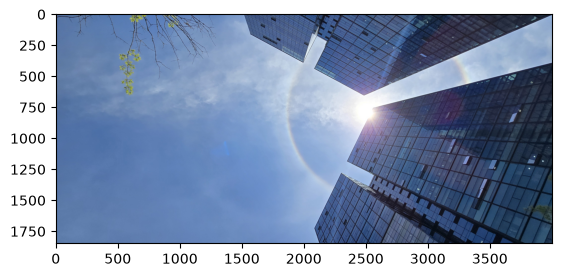

In [5]:
img1 = cv2.imread("../data/sample.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
plt.imshow(img1)

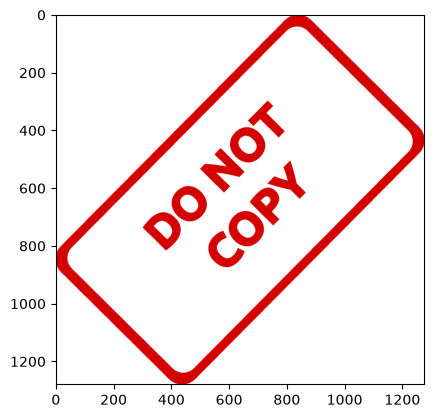

In [6]:
img2 = cv2.imread("../data/watermark_no_copy.png")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(img2)

In [7]:
blended = cv2.addWeighted(src1=img1, alpha=0.5, src2=img2, beta=0.5, gamma=0)
plt.imshow(blended)

error: OpenCV(4.11.0) /io/opencv/modules/core/src/arithm.cpp:662: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'arithm_op'


In [9]:
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
img1.shape, img2.shape

((1848, 4000, 3), (1848, 4000, 3))

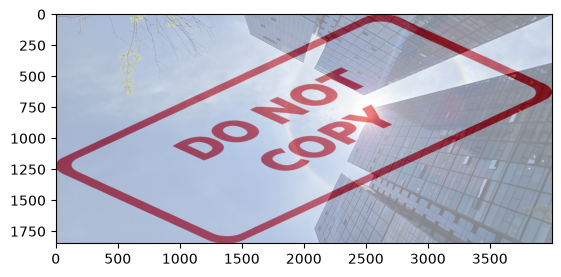

In [11]:
blended = cv2.addWeighted(src1=img1, alpha=0.5, src2=img2, beta=0.5, gamma=0)
plt.imshow(blended)

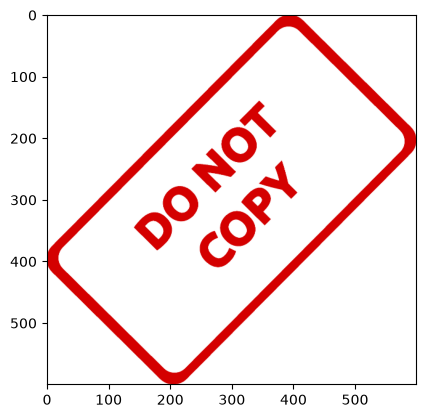

In [13]:
img2 = cv2.resize(img2, (600, 600))
plt.imshow(img2)

In [15]:
large_img = img1
small_img = img2

x_offset = 0
y_offset = 0

In [17]:
x_end = x_offset + small_img.shape[1]
y_end = y_offset + small_img.shape[0]

large_img[y_offset:y_end, x_offset:y_end] = small_img

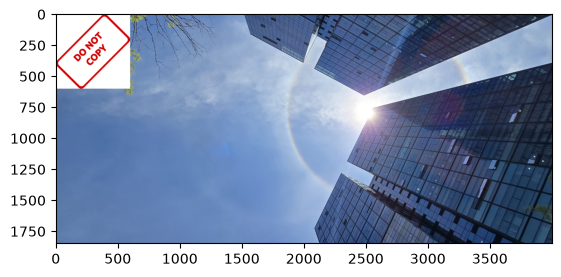

In [18]:
plt.imshow(large_img)

In [20]:
img1 = cv2.imread("../data/sample.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread("../data/watermark_no_copy.png")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2 = cv2.resize(img2, (600, 600))

img1.shape, img2.shape

((1848, 4000, 3), (600, 600, 3))

In [22]:
x_offset = img1.shape[1] - img2.shape[1]
y_offset = img1.shape[0] - img2.shape[0]
x_offset, y_offset

(3400, 1248)

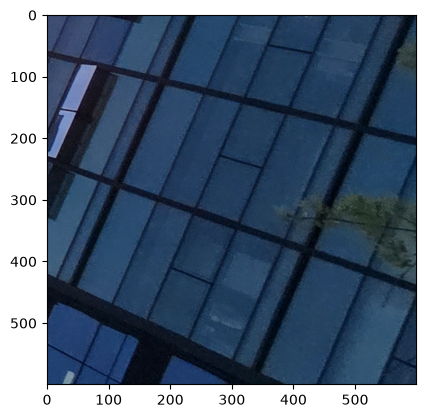

In [24]:
roi = img1[y_offset : img1.shape[0], x_offset : img1.shape[1]]
plt.imshow(roi)

- ROI
    - Region of Interest, 관심 영역
    - 영상에서 특정 연산을 수행하고자 하는 임의의 부분 영역

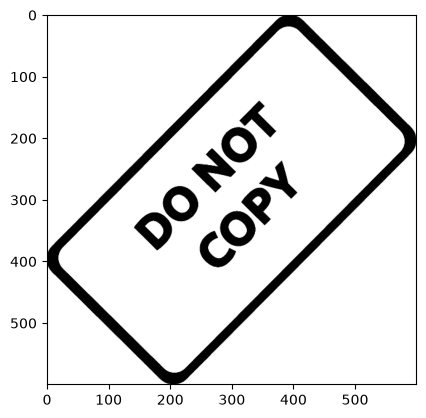

In [25]:
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
plt.imshow(img2_gray, cmap="gray")

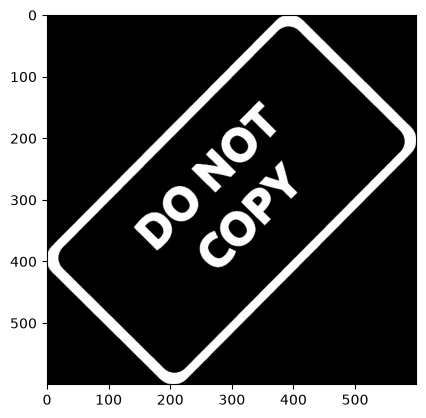

In [27]:
mask_inv = cv2.bitwise_not(img2_gray)
plt.imshow(mask_inv, cmap="gray")

In [28]:
mask_inv.shape

(600, 600)

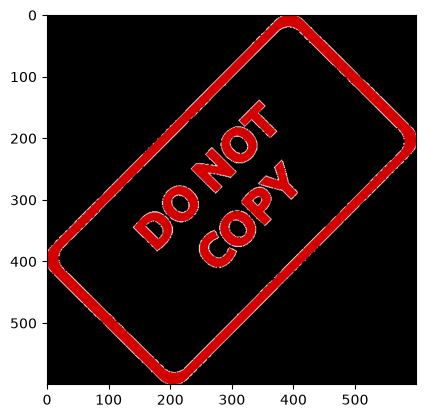

In [29]:
fg = cv2.bitwise_or(img2, img2, mask=mask_inv)
plt.imshow(fg)

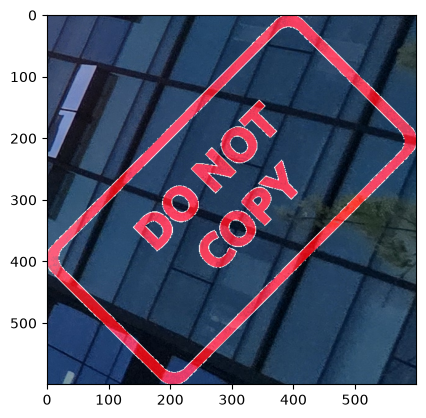

In [30]:
final_roi = cv2.bitwise_or(roi, fg)
plt.imshow(final_roi)

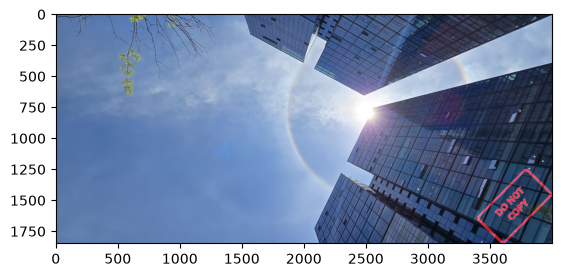

In [31]:
img1[y_offset : y_offset + img1.shape[0], x_offset : x_offset + img2.shape[1]] = (final_roi)
plt.imshow(img1)

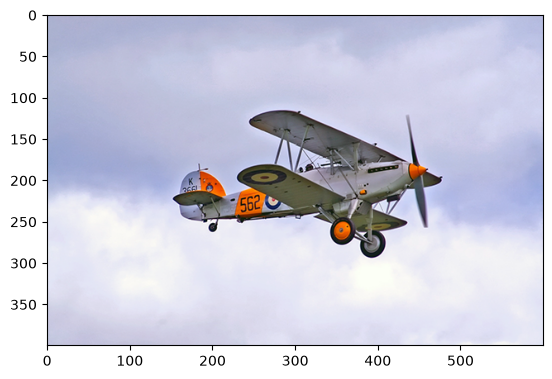

In [32]:
src = cv2.imread("../data/airplane.bmp")
src = cv2.cvtColor(src, cv2.COLOR_BGR2RGB)
plt.imshow(src)

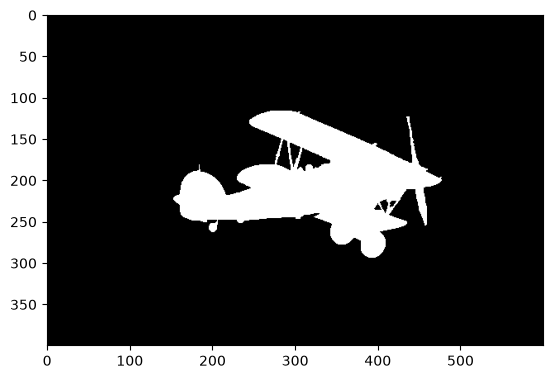

In [33]:
mask = cv2.imread("../data/mask_plane.bmp", cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap="gray")

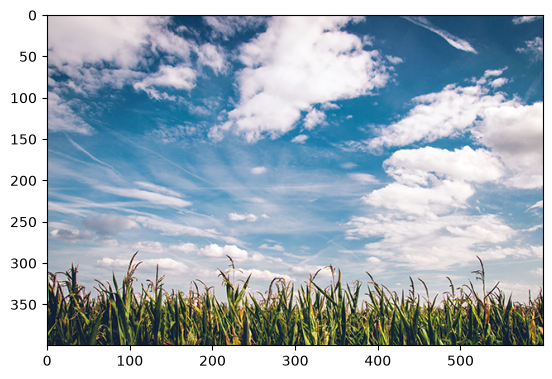

In [34]:
dst = cv2.imread("../data/field.bmp")
dst = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
plt.imshow(dst)

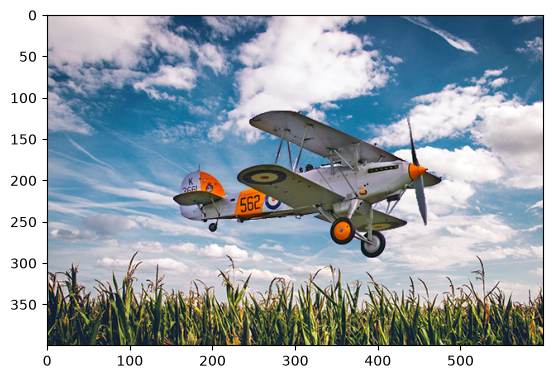

In [35]:
plt.imshow(cv2.copyTo(src, mask, dst))